In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (7, 3.2), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
NAVY, BLUE, RED, GREY = '#1E2761', '#1A73E8', '#C0392B', '#9AA5B1'

# AI-Powered Fraud Detection
### Fraud Detection Initiative — Technical Presentation

Emmanuel Tan · AIM PGAIML Capstone · September 2026

## Problem Statement

Manual review and one-size-fits-all rule-based tagging cannot keep up with the growing volume of digital and mobile-banking transactions. The goal of this model is to flag high-risk transactions for review **before** the fraud payout happens.

| | |
|---|---|
| **Task type** | Binary classification (fraud vs legitimate) |
| **Primary metrics** | PR-AUC and Recall on the fraud class — not Accuracy, due to the 0.129% fraud rate |
| **Business KPI** | Fraud $ prevented, net of the cost of reviewing false positives |

## Synthetic Dataset — PaySim

| Transactions | Fraud rate | Columns |
|:---:|:---:|:---:|
| **6.36M** | **0.129%** | **11** |

- **Class imbalance:** 6,354,407 legitimate vs 8,213 fraud transactions
- A model that always predicts "legitimate" would be **99.87% accurate** — and catch zero fraud.

## EDA — Fraud Rate per Transaction Type

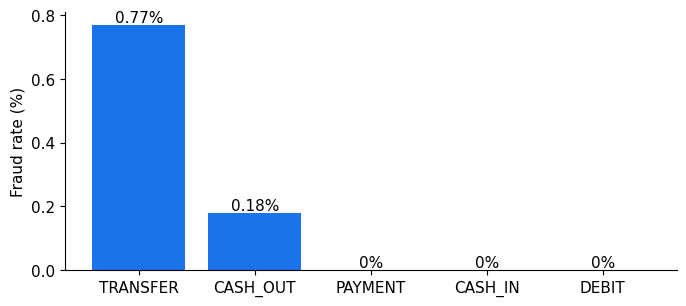

In [2]:
types = ['TRANSFER', 'CASH_OUT', 'PAYMENT', 'CASH_IN', 'DEBIT']
rates = [0.77, 0.18, 0, 0, 0]
bars = plt.bar(types, rates, color=[BLUE, BLUE, GREY, GREY, GREY])
plt.bar_label(bars, labels=[f'{r}%' for r in rates])
plt.ylabel('Fraud rate (%)'); plt.tight_layout(); plt.show()

Fraud only occurs in **TRANSFER** and **CASH_OUT** — the types that can drain a customer account.
CASH_IN adds to the balance, PAYMENT goes to merchant accounts, and DEBIT transactions are too small in scale (max $569K vs $1.47M average fraud).

## Feature Engineering and Selection

- **errorBalanceOrig / errorBalanceDest** — balance-mismatch features; 99.45% of fraud lands within $1 of zero vs 21.3% of legitimate transactions
- **isMerchantDest** — flags merchant destination accounts (no fraud by transaction structure)
- **Selection cross-checked** with Random Forest importance and mutual information — both rank errorBalanceOrig first (0.399 / 0.191)
- **type_CASH_OUT kept** despite low scores — fraud is only possible in CASH_OUT and TRANSFER

## Modelling Approach

| Model | Setup |
|---|---|
| Logistic Regression | Linear baseline, scaled features, class_weight = balanced |
| Random Forest | 100 trees, max_depth = 10, class_weight = balanced |
| XGBoost | Tuned scale_pos_weight |

**Class weighting, not SMOTE:** oversampling would synthesize ~4.4M fake fraud rows on top of ~5,750 real ones.
Stratified 70/30 split preserves the real 0.129% fraud rate in both sets.

## Model Comparison (test set)

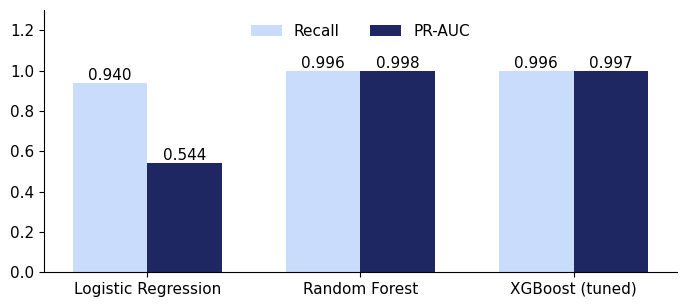

In [3]:
import numpy as np
models = ['Logistic Regression', 'Random Forest', 'XGBoost (tuned)']
recall, prauc = [0.940, 0.996, 0.996], [0.544, 0.998, 0.997]
x = np.arange(3); w = 0.35
b1 = plt.bar(x - w/2, recall, w, label='Recall', color='#CADCFC')
b2 = plt.bar(x + w/2, prauc, w, label='PR-AUC', color=NAVY)
plt.bar_label(b1, fmt='%.3f'); plt.bar_label(b2, fmt='%.3f')
plt.xticks(x, models); plt.ylim(0, 1.3); plt.legend(loc='upper center', ncol=2, frameon=False)
plt.tight_layout(); plt.show()

- **Existing rule-based system:** 16 / 8,213 fraud cases flagged (full dataset, 0.19%)
- **Random Forest:** 2,455 / 2,464 caught (test set), with zero false positives

## Critical Finding 1 — Default Hyperparameters Check

XGBoost's class-ratio weight hurt performance

| scale_pos_weight | Precision | PR-AUC |
|:---:|:---:|:---:|
| 774 (class ratio) | 0.159 | 0.158 |
| 1 | 0.999 | 0.997 |

A mathematically justified setting actively hurt Precision, with no gain in Recall.

## Critical Finding 2 — Near-Perfect Score Is Feature-Dependent

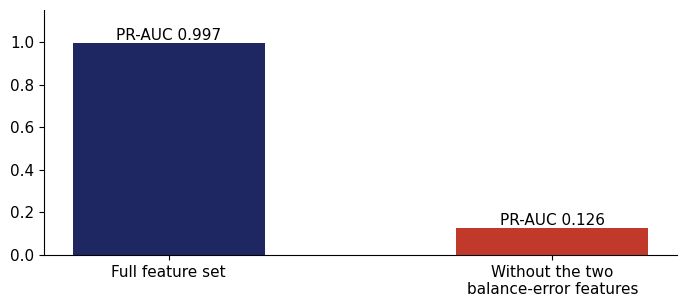

In [4]:
bars = plt.bar(['Full feature set', 'Without the two\nbalance-error features'],
               [0.997, 0.126], color=[NAVY, RED], width=0.5)
plt.bar_label(bars, fmt='PR-AUC %.3f'); plt.ylim(0, 1.15)
plt.tight_layout(); plt.show()

PaySim forces newbalanceOrig to 0 on fraudulent transfers — a caveat on every headline metric.

## Explainability and Fairness

**SHAP ranking (mean |SHAP|):** errorBalanceOrig ≫ newbalanceOrig > oldbalanceOrg > amount > type_TRANSFER

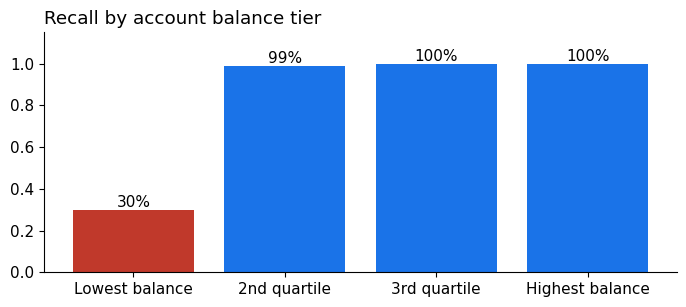

In [5]:
tiers = ['Lowest balance', '2nd quartile', '3rd quartile', 'Highest balance']
recall = [0.30, 0.99, 1.00, 1.00]
bars = plt.bar(tiers, recall, color=[RED, BLUE, BLUE, BLUE])
plt.bar_label(bars, labels=[f'{r:.0%}' for r in recall]); plt.ylim(0, 1.15)
plt.title('Recall by account balance tier', loc='left'); plt.tight_layout(); plt.show()

- Precision is 1.0 in all tiers; the lowest-balance quartile may be **under-protected**
- Equalized odds: TPR gap = 0.70, FPR gap = 0

## Limitations & Next Steps

**Limitations**
- Recall disparity across account-balance tiers still to be resolved
- No customer demographics in the synthetic dataset
- Synthetic data — not yet tested against live data

**Next steps**
- Secure project approval, funding and personnel (working group, compliance and risk teams)
- Parallel run with the existing rule-based flagging against live data
- Investigate the fix for the account-balance disparity